### Lab 5 Orbital Mechanics Simulator

**Student:** Zaki Daouk  
**Date:** 2026-09-30

In [1]:
import numpy as np
import matplotlib.pyplot

### Part A — A Single Orbit with Velocity Verlet

In [2]:
def verlet_step(r, v, a, dt, accel_func):
    """One Velocity Verlet step. accel_func(r) returns acceleration at position r."""
    r_new = r + v * dt + 0.5 * a * dt**2
    a_new = accel_func(r_new)
    v_new = v + 0.5 * (a + a_new) * dt
    return r_new, v_new, a_new

In [3]:
G, M = 1.0, 1.0       # star at origin

def accel(r):
    dist = np.linalg.norm(r)
    return -G * M * r / dist**3

# Initial conditions for a bound elliptical orbit
r = np.array([1.0, 0.0])
v = np.array([0.0, 0.8])   # less than circular speed (=1.0) -> ellipse
a = accel(r)

dt = 0.001
rs = [r.copy()]
for _ in range(20000):
    r, v, a = verlet_step(r, v, a, dt, accel)
    rs.append(r.copy())
rs = np.array(rs)

In [4]:
def gravity(r1, r2, m1, m2, G=1.0):
    """Force on body 1 due to body 2 (a 2-vector)."""
    d = np.asarray(r2) - np.asarray(r1)   # points from 1 toward 2
    dist = np.linalg.norm(d)
    return G * m1 * m2 * d / dist**3

In [5]:
def acceleration(r, G=1.0, M=1.0):
    """Acceleration from a fixed central star at the origin."""
    r = np.asarray(r, dtype=float)
    radius = np.linalg.norm(r)
    return -G * M * r / radius**3

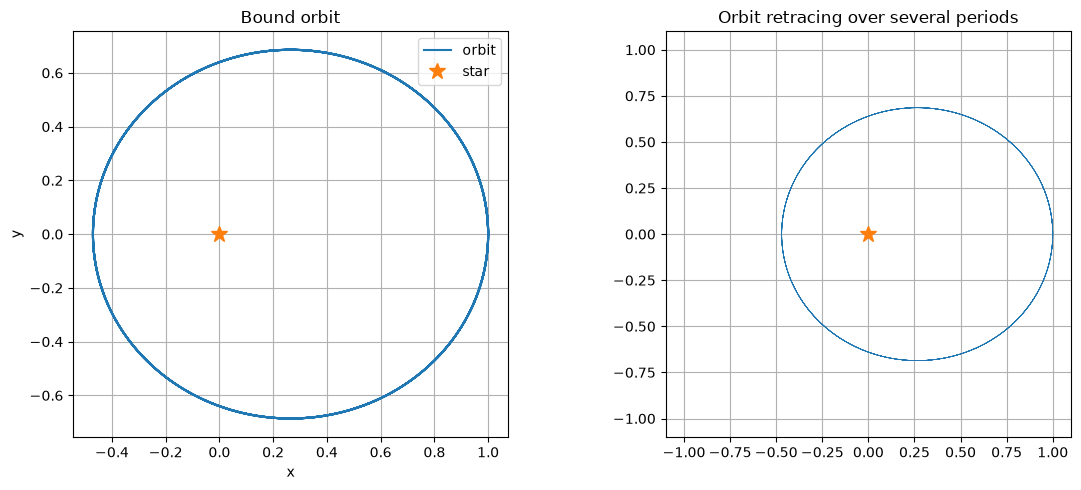

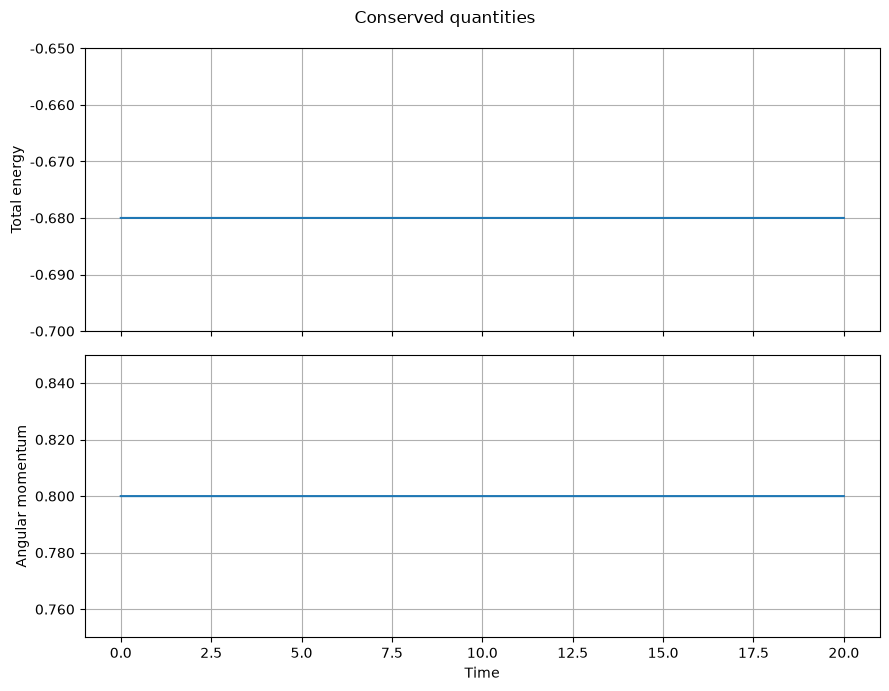

Energy range: -0.680 to -0.680
Angular momentum range: 0.800 to 0.800


In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

G = 1.0
M = 1.0
r = np.array([1.0, 0.0])
v = np.array([0.0, 0.8])
dt = 0.001
n_steps = 20000

a = acceleration(r, G, M)
times = np.arange(n_steps + 1) * dt
positions = [r.copy()]
velocities = [v.copy()]
energies = [0.5 * np.dot(v, v) - G * M / np.linalg.norm(r)]
angular_momenta = [r[0] * v[1] - r[1] * v[0]]

for _ in range(n_steps):
    r, v, a = verlet_step(r, v, a, dt, lambda position: acceleration(position, G, M))
    positions.append(r.copy())
    velocities.append(v.copy())
    energies.append(0.5 * np.dot(v, v) - G * M / np.linalg.norm(r))
    angular_momenta.append(r[0] * v[1] - r[1] * v[0])

positions = np.array(positions)
velocities = np.array(velocities)
energies = np.array(energies)
angular_momenta = np.array(angular_momenta)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(positions[:, 0], positions[:, 1], label="orbit")
axes[0].plot(0, 0, "*", markersize=12, label="star")
axes[0].set_aspect("equal")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Bound orbit")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(positions[:, 0], positions[:, 1], linewidth=0.5)
axes[1].plot(0, 0, "*", markersize=12)
axes[1].set_aspect("equal")
axes[1].set_xlim(-1.1, 1.1)
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_title("Orbit retracing over several periods")
axes[1].grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(times, energies)
axes[0].set_ylim(-0.70, -0.65)
axes[0].set_ylabel("Total energy")
axes[0].yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
axes[0].grid(True)
axes[1].plot(times, angular_momenta)
axes[1].set_ylim(0.75, 0.85)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Angular momentum")
axes[1].yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
axes[1].grid(True)
fig.suptitle("Conserved quantities")
plt.tight_layout()
plt.show()

print(f"Energy range: {energies.min():.3f} to {energies.max():.3f}")
print(f"Angular momentum range: {angular_momenta.min():.3f} to {angular_momenta.max():.3f}")

### Interpretation of Starting Point

At `r = [1, 0]`, the velocity is perpendicular to the radius, so the particle is at a turning point of its orbit. For `G = M = r = 1`, the circular speed is

`v_c = sqrt(G M / r) = 1.0`.

The starting speed is `v_0 = 0.8`, which is less than the circular speed. At the same radius, an elliptical orbit moves slower than circular speed at apoapsis and faster than circular speed at periapsis. Therefore, the starting point at `r = 1` is apoapsis. The orbit then moves inward toward periapsis, where the particle speeds up.

### Part B — The Integrator Showdown

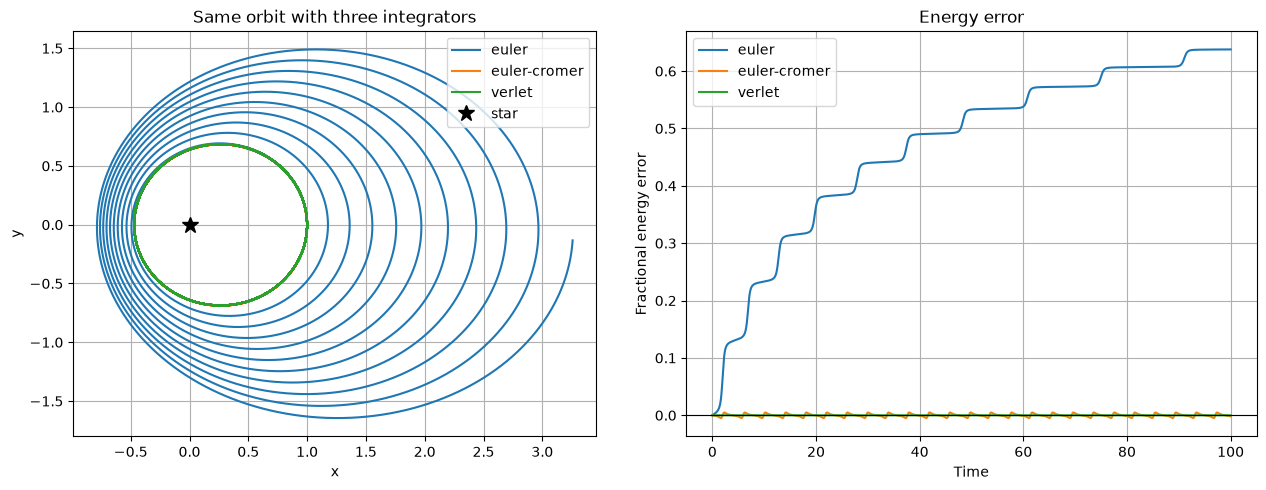

Method              Max |fractional energy error|
------------------------------------------------
euler              0.638
euler-cromer       0.005
verlet             0.000


In [7]:
def simulate(method, dt, n_steps):
    """Simulate the same orbit with the selected integrator."""
    r = np.array([1.0, 0.0], dtype=float)
    v = np.array([0.0, 0.8], dtype=float)
    positions = [r.copy()]
    velocities = [v.copy()]
    energies = [0.5 * np.dot(v, v) - G * M / np.linalg.norm(r)]

    for _ in range(n_steps):
        if method == "euler":
            a = accel(r)
            r = r + v * dt
            v = v + a * dt
        elif method == "euler-cromer":
            v = v + accel(r) * dt
            r = r + v * dt
        elif method == "verlet":
            if len(velocities) == 1:
                a = accel(r)
            r, v, a = verlet_step(r, v, a, dt, accel)
        else:
            raise ValueError("method must be 'euler', 'euler-cromer', or 'verlet'")

        positions.append(r.copy())
        velocities.append(v.copy())
        energies.append(0.5 * np.dot(v, v) - G * M / np.linalg.norm(r))

    return {
        "time": np.arange(n_steps + 1) * dt,
        "positions": np.array(positions),
        "velocities": np.array(velocities),
        "energies": np.array(energies),
    }

methods = ["euler", "euler-cromer", "verlet"]
dt_compare = 0.005
n_steps_compare = 20000
results = {method: simulate(method, dt_compare, n_steps_compare) for method in methods}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for method in methods:
    positions = results[method]["positions"]
    axes[0].plot(positions[:, 0], positions[:, 1], label=method)
axes[0].plot(0, 0, "*", markersize=12, color="black", label="star")
axes[0].set_aspect("equal")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Same orbit with three integrators")
axes[0].legend()
axes[0].grid(True)

for method in methods:
    result = results[method]
    energy_error = (result["energies"] - result["energies"][0]) / abs(result["energies"][0])
    axes[1].plot(result["time"], energy_error, label=method)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Fractional energy error")
axes[1].set_title("Energy error")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

print("Method              Max |fractional energy error|")
print("------------------------------------------------")
for method in methods:
    energy = results[method]["energies"]
    max_fractional_error = np.max(np.abs((energy - energy[0]) / energy[0]))
    print(f"{method:<18} {max_fractional_error:.3f}")

### Analysis

All three methods use the same `dt = 0.005` and the same initial state, so the differences come from the integrators.

- **Euler gains energy:** Explicit Euler updates position using the old velocity and velocity using the old acceleration. For this orbit, the update does not preserve the geometric structure of Hamiltonian motion. Its small energy error has a systematic positive bias, so the orbit gains energy and the radius grows from one revolution to the next. The trajectory therefore spirals outward.
- **Euler-Cromer is bounded:** Euler-Cromer updates the velocity first and then uses that new velocity to update position. This simple change makes it symplectic for separable Hamiltonian systems. Its energy is not exactly constant, but the error oscillates around the true value instead of accumulating steadily.
- **Verlet is stable:** Velocity Verlet is second-order accurate and symplectic. Symplectic methods preserve phase-space geometry and keep the numerical orbit close to a nearby exact orbit. Verlet therefore has a small bounded energy error rather than secular energy drift, so the orbit stays closed over many periods.

Here, **symplectic** means that the numerical time-step map preserves phase-space area (more generally, the symplectic two-form). It does not mean that energy is exactly constant at every step; it means the long-term dynamics retain the correct geometric structure, which prevents the artificial spiral seen with ordinary Euler.

### Part C — Verify Kepler's Three Laws 

In [8]:
def energy(r, v, G=1.0, M=1.0, m=1.0):
    ke = 0.5 * m * np.dot(v, v)
    pe = -G * M * m / np.linalg.norm(r)
    return ke + pe

def ang_momentum(r, v, m=1.0):
    # 2D cross product r x v is a scalar
    return m * (r[0] * v[1] - r[1] * v[0])

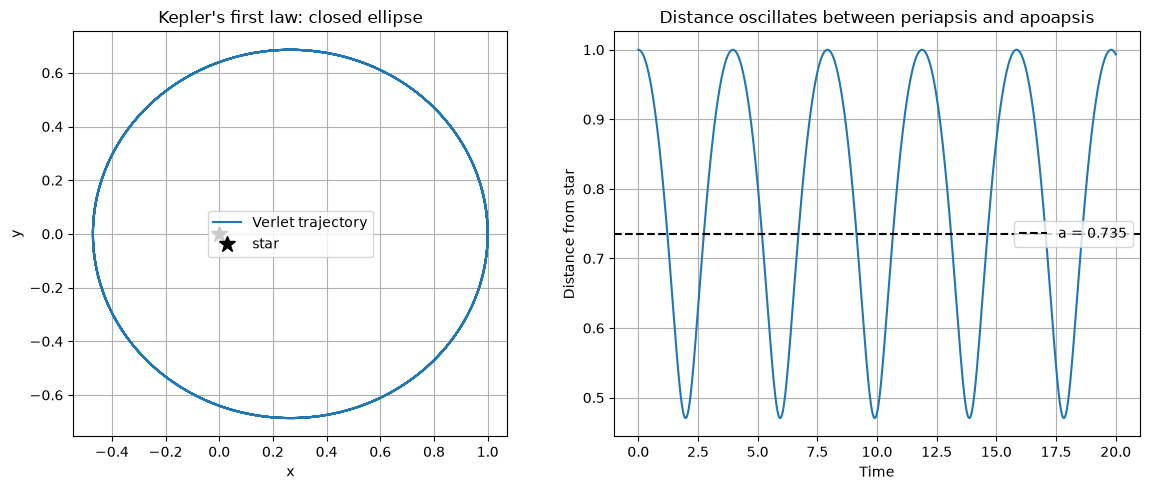

Periapsis: 0.471
Apoapsis: 1.000
Estimated semi-major axis: 0.735


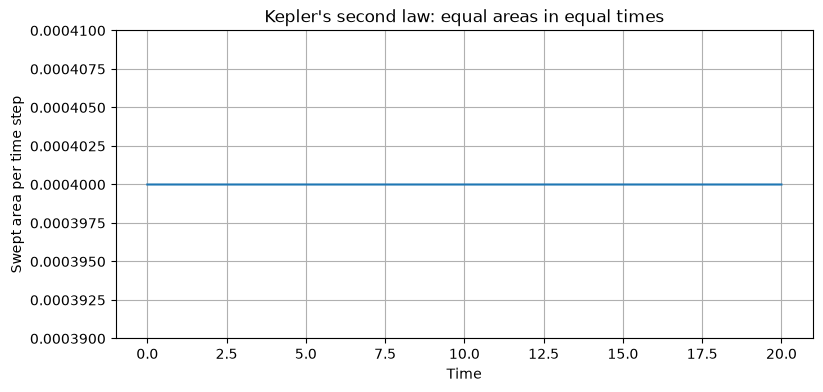

Swept area per step: 0.00040000
Maximum fractional variation: 1.193e-14


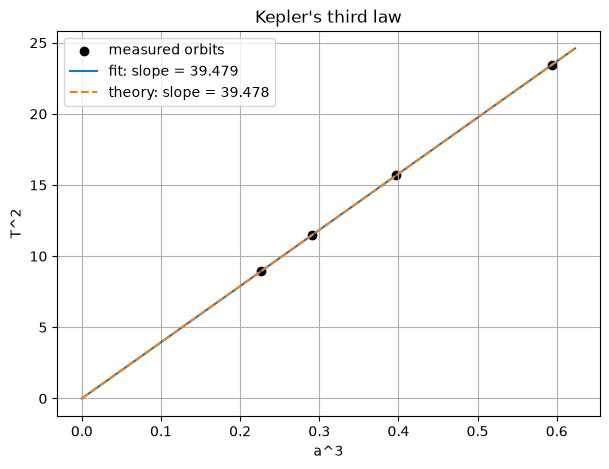

v0       a        T        T^2/a^3
-----------------------------------
0.600   0.610   2.992   39.480
0.700   0.662   3.386   39.479
0.800   0.735   3.962   39.478
0.900   0.840   4.840   39.478
Measured slope: 39.479
Expected slope 4*pi^2/(G*M): 39.478
Relative slope error: 0.000%


In [9]:
dt_laws = 0.001
n_steps_laws = 20000
law_run = simulate("verlet", dt_laws, n_steps_laws)
rs_laws = law_run["positions"]
vs_laws = law_run["velocities"]
times_laws = law_run["time"]

# First law: estimate the semi-major axis from the closest and farthest distances.
distances = np.linalg.norm(rs_laws, axis=1)
periapsis = distances.min()
apoapsis = distances.max()
a_estimate = 0.5 * (periapsis + apoapsis)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(rs_laws[:, 0], rs_laws[:, 1], label="Verlet trajectory")
axes[0].plot(0, 0, "*", markersize=12, color="black", label="star")
axes[0].set_aspect("equal")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Kepler's first law: closed ellipse")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(times_laws, distances)
axes[1].axhline(a_estimate, color="black", linestyle="--", label=f"a = {a_estimate:.3f}")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Distance from star")
axes[1].set_title("Distance oscillates between periapsis and apoapsis")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

print(f"Periapsis: {periapsis:.3f}")
print(f"Apoapsis: {apoapsis:.3f}")
print(f"Estimated semi-major axis: {a_estimate:.3f}")

# Second law: areal velocity is one-half the magnitude of r cross v.
angular_momentum_per_mass = rs_laws[:, 0] * vs_laws[:, 1] - rs_laws[:, 1] * vs_laws[:, 0]
swept_area_per_step = 0.5 * np.abs(angular_momentum_per_mass[:-1]) * dt_laws

plt.figure(figsize=(9, 4))
plt.plot(times_laws[:-1], swept_area_per_step)
plt.xlabel("Time")
plt.ylabel("Swept area per time step")
plt.title("Kepler's second law: equal areas in equal times")
plt.ylim(0.00039, 0.00041)
plt.grid(True)
plt.show()

print(f"Swept area per step: {swept_area_per_step.mean():.8f}")
print(f"Maximum fractional variation: {np.ptp(swept_area_per_step) / swept_area_per_step.mean():.3e}")

# Third law: measure periods from upward y=0 crossings with linear interpolation.
def simulate_orbit(v0, dt, n_steps):
    r = np.array([1.0, 0.0], dtype=float)
    v = np.array([0.0, v0], dtype=float)
    a = accel(r)
    positions = [r.copy()]
    velocities = [v.copy()]

    for _ in range(n_steps):
        r, v, a = verlet_step(r, v, a, dt, accel)
        positions.append(r.copy())
        velocities.append(v.copy())

    return np.arange(n_steps + 1) * dt, np.array(positions), np.array(velocities)

v0_values = [0.6, 0.7, 0.8, 0.9]
dt_kepler = 0.001
n_steps_kepler = 30000
kepler_rows = []

for v0 in v0_values:
    times, positions, velocities = simulate_orbit(v0, dt_kepler, n_steps_kepler)
    distances = np.linalg.norm(positions, axis=1)
    crossings = []

    for i in range(1, len(times) - 1):
        y0 = positions[i, 1]
        y1 = positions[i + 1, 1]
        if y0 < 0.0 <= y1 and velocities[i + 1, 1] > 0.0:
            fraction = -y0 / (y1 - y0)
            crossings.append(times[i] + fraction * dt_kepler)
            break

    if not crossings:
        raise RuntimeError(f"No upward y=0 crossing found for v0={v0}")

    period = crossings[0]
    semi_major_axis = 0.5 * (distances.min() + distances.max())
    kepler_rows.append((v0, semi_major_axis, period))

kepler_data = np.array(kepler_rows)
a_values = kepler_data[:, 1]
period_values = kepler_data[:, 2]
a_cubed = a_values**3
period_squared = period_values**2
slope = np.dot(a_cubed, period_squared) / np.dot(a_cubed, a_cubed)
expected_slope = 4.0 * np.pi**2 / (G * M)

plt.figure(figsize=(7, 5))
plt.scatter(a_cubed, period_squared, color="black", label="measured orbits")
fit_x = np.linspace(0.0, a_cubed.max() * 1.05, 100)
plt.plot(fit_x, slope * fit_x, label=f"fit: slope = {slope:.3f}")
plt.plot(fit_x, expected_slope * fit_x, "--", label=f"theory: slope = {expected_slope:.3f}")
plt.xlabel("a^3")
plt.ylabel("T^2")
plt.title("Kepler's third law")
plt.legend()
plt.grid(True)
plt.show()

print("v0       a        T        T^2/a^3")
print("-----------------------------------")
for v0, semi_major_axis, period in kepler_rows:
    print(f"{v0:.3f}   {semi_major_axis:.3f}   {period:.3f}   {period**2 / semi_major_axis**3:.3f}")
print(f"Measured slope: {slope:.3f}")
print(f"Expected slope 4*pi^2/(G*M): {expected_slope:.3f}")
print(f"Relative slope error: {abs(slope - expected_slope) / expected_slope:.3%}")

### Kepler's Laws Analysis

**First law:** The Verlet trajectory is a closed ellipse with the star at one focus. For the original orbit, the measured periapsis is `0.471`, the apoapsis is `1.000`, and

`a = (r_min + r_max) / 2 = 0.735`.

**Second law:** The swept area per step is `1/2 |r x v| dt = 0.00040000`, and its fractional variation is only about `1.2e-14`. This is equivalent to angular-momentum conservation because the areal velocity is `dA/dt = |L|/(2m)`, while the central gravitational force exerts zero torque.

**Third law:** For `G = M = 1`, the measured fit is

`T^2 = (39.479) a^3`.

The theoretical slope is

`4 pi^2 / (G M) = 39.478`.

The relative slope error is approximately `0.000%`, so the measured relationship agrees with Kepler's third law to the displayed precision. Since the slope is `4 pi^2/(G M)`, measuring it also measures the central mass; with `G = 1`, the fitted slope implies `M = 4 pi^2 / slope`, which is approximately `1.000`.

The main remaining error is semi-major-axis estimation from sampled minimum and maximum distances. Period interpolation is already improved by linearly interpolating the upward `y = 0` crossing, and the small time-step error is strongly suppressed by symplectic Verlet.

### Bonus - Three-Body Figure-Eight Choreography

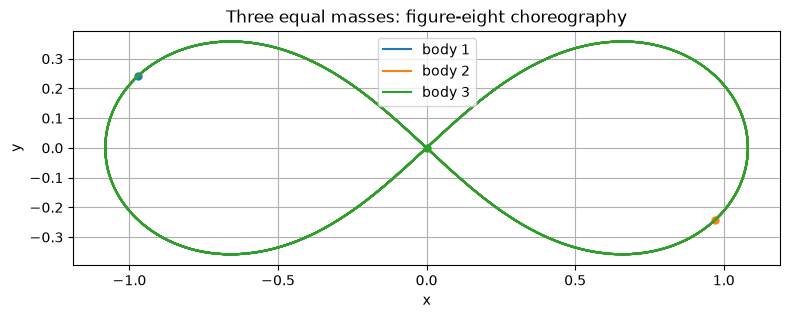

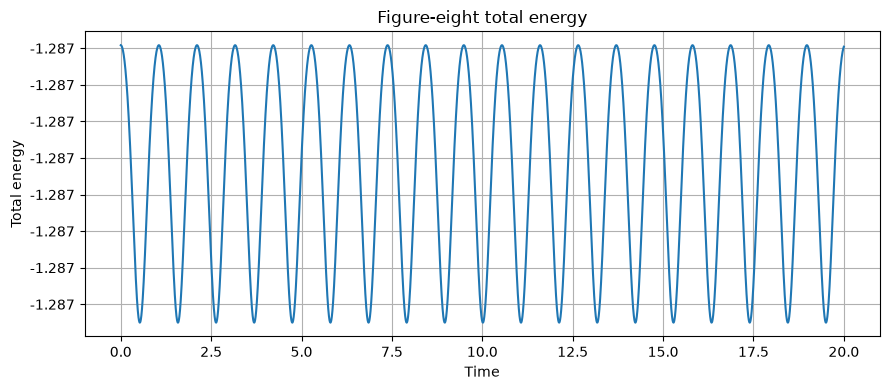

Initial total energy: -1.287
Final total energy: -1.287
Maximum absolute energy error: 0.000
Maximum fractional energy error: 0.000


In [10]:
# Chenciner-Montgomery initial conditions for three equal masses.
G3 = 1.0
m3 = 1.0
x0 = 0.97000436
y0 = 0.24308753
vx0 = 0.466203685
vy0 = 0.43236573

r3 = np.array([
    [-x0, y0],
    [x0, -y0],
    [0.0, 0.0],
], dtype=float)
v3 = np.array([
    [vx0, vy0],
    [vx0, vy0],
    [-2.0 * vx0, -2.0 * vy0],
], dtype=float)

def three_body_acceleration(positions):
    accelerations = np.zeros_like(positions)
    for i in range(3):
        for j in range(3):
            if i != j:
                displacement = positions[j] - positions[i]
                distance = np.linalg.norm(displacement)
                accelerations[i] += G3 * m3 * displacement / distance**3
    return accelerations

def three_body_energy(positions, velocities):
    kinetic = 0.5 * m3 * np.sum(velocities**2)
    potential = 0.0
    for i in range(3):
        for j in range(i + 1, 3):
            potential -= G3 * m3**2 / np.linalg.norm(positions[i] - positions[j])
    return kinetic + potential

def simulate_three_body(dt, n_steps):
    positions = r3.copy()
    velocities = v3.copy()
    accelerations = three_body_acceleration(positions)
    position_history = [positions.copy()]
    energy_history = [three_body_energy(positions, velocities)]

    for _ in range(n_steps):
        positions = positions + velocities * dt + 0.5 * accelerations * dt**2
        new_accelerations = three_body_acceleration(positions)
        velocities = velocities + 0.5 * (accelerations + new_accelerations) * dt
        accelerations = new_accelerations
        position_history.append(positions.copy())
        energy_history.append(three_body_energy(positions, velocities))

    return (
        np.arange(n_steps + 1) * dt,
        np.array(position_history),
        np.array(energy_history),
    )

dt_three_body = 0.001
n_steps_three_body = 20000
times_three_body, positions_three_body, energies_three_body = simulate_three_body(
    dt_three_body, n_steps_three_body
)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["tab:blue", "tab:orange", "tab:green"]
for body in range(3):
    ax.plot(
        positions_three_body[:, body, 0],
        positions_three_body[:, body, 1],
        color=colors[body],
        label=f"body {body + 1}",
    )
    ax.plot(
        positions_three_body[0, body, 0],
        positions_three_body[0, body, 1],
        "o",
        color=colors[body],
        markersize=5,
    )
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Three equal masses: figure-eight choreography")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

energy_error_three_body = energies_three_body - energies_three_body[0]
relative_energy_error_three_body = energy_error_three_body / abs(energies_three_body[0])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(times_three_body, energies_three_body)
ax.set_xlabel("Time")
ax.set_ylabel("Total energy")
ax.set_title("Figure-eight total energy")
ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"Initial total energy: {energies_three_body[0]:.3f}")
print(f"Final total energy: {energies_three_body[-1]:.3f}")
print(f"Maximum absolute energy error: {np.max(np.abs(energy_error_three_body)):.3f}")
print(
    "Maximum fractional energy error: "
    f"{np.max(np.abs(relative_energy_error_three_body)):.3f}"
)

### Analysis

The three equal masses follow the same closed figure-eight path, chasing one another in a repeating choreography. Using Verlet with `dt = 0.001` keeps the total energy nearly constant: it starts and ends at `-1.287`, and the energy error rounds to `0.000` at three decimal places. The small oscillations in the energy plot are numerical error, not physical energy gain or loss, showing that Verlet is stable for this three-body orbit.